In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/hour.csv')
print(df.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [4]:
df=df.drop(columns=["casual","registered","instant","dteday"])
print(df.head())

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  


In [5]:
categorical_cols = [
    "season",
    "weathersit",
    "holiday",
    "workingday",
    "weekday"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")

    print("Counts:")
    print(df[col].value_counts())

    print("\nProportions:")
    print(df[col].value_counts(normalize=True))

    print("\nMean cnt:")
    print(df.groupby(col)["cnt"].mean())

    print("unique")
    print(df[col].nunique())


===== season =====
Counts:
season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64

Proportions:
season
3    0.258703
2    0.253697
1    0.244088
4    0.243512
Name: proportion, dtype: float64

Mean cnt:
season
1    111.114569
2    208.344069
3    236.016237
4    198.868856
Name: cnt, dtype: float64
unique
4

===== weathersit =====
Counts:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

Proportions:
weathersit
1    0.656712
2    0.261465
3    0.081650
4    0.000173
Name: proportion, dtype: float64

Mean cnt:
weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64
unique
4

===== holiday =====
Counts:
holiday
0    16879
1      500
Name: count, dtype: int64

Proportions:
holiday
0    0.97123
1    0.02877
Name: proportion, dtype: float64

Mean cnt:
holiday
0    190.42858
1    156.87000
Name: cnt, dtype: float64
unique
2

===== workingday =====
Counts:
workingday
1    11865
0     5514
Name: cou

In [6]:
df[df["weathersit"] == 4]

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
585,1,0,1,16,0,3,1,4,0.22,0.1970,0.93,0.3284,36
8854,1,1,1,18,0,1,1,4,0.20,0.2273,0.86,0.0896,164
9123,1,1,1,1,0,6,0,4,0.14,0.1364,0.86,0.1940,23


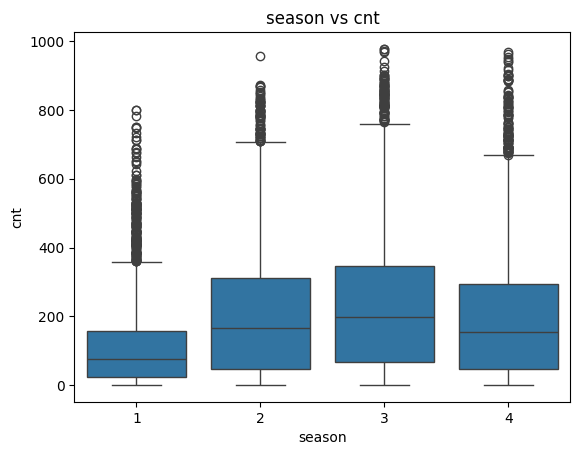

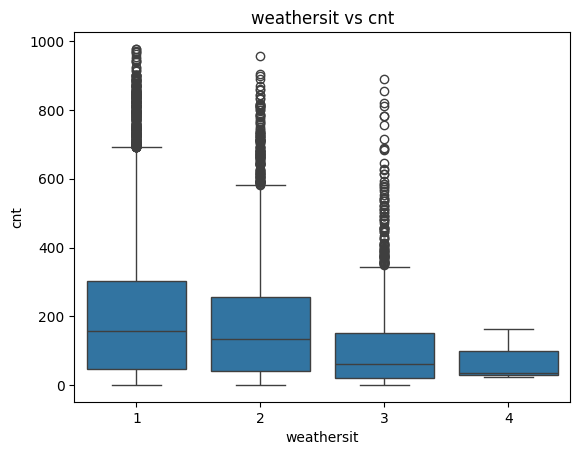

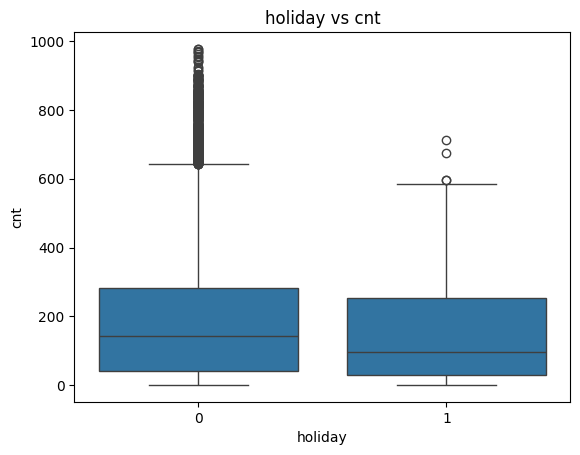

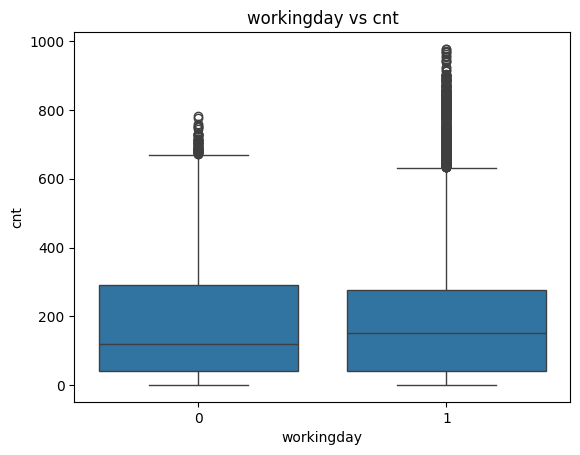

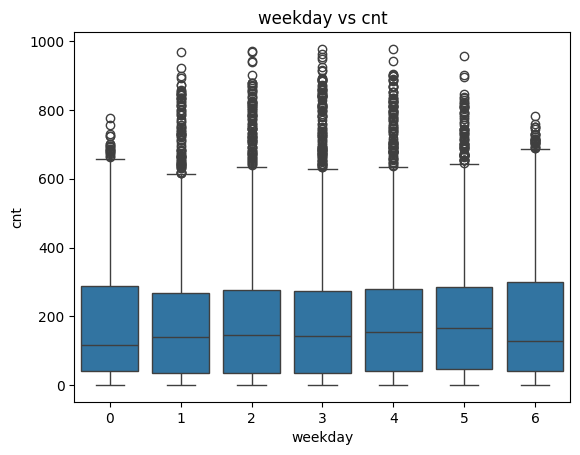

In [7]:
for col in categorical_cols:
    sns.boxplot(x=col, y="cnt", data=df)
    plt.title(f"{col} vs cnt")
    plt.show()

**continuous** **category**

In [8]:
continuous_cols = ["temp", "atemp", "hum", "windspeed"]

In [9]:
for col in continuous_cols:
    print(f"\n===== {col} =====")
    print("Skewness:", df[col].skew())


===== temp =====
Skewness: -0.00602088334827027

===== atemp =====
Skewness: -0.09042885855903955

===== hum =====
Skewness: -0.11128714936537845

===== windspeed =====
Skewness: 0.5749052034923136


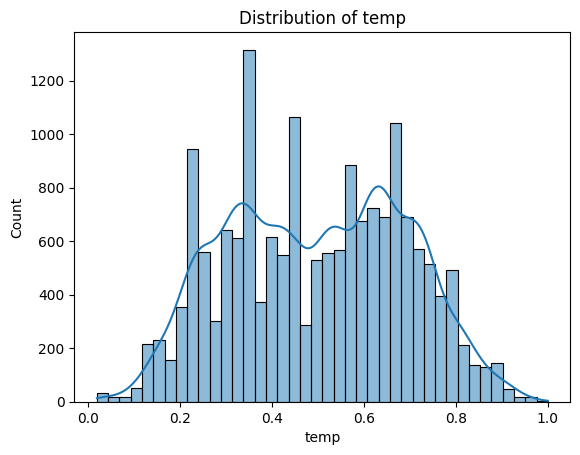

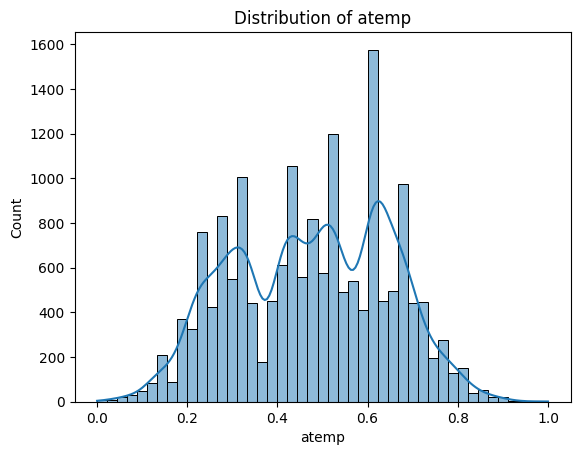

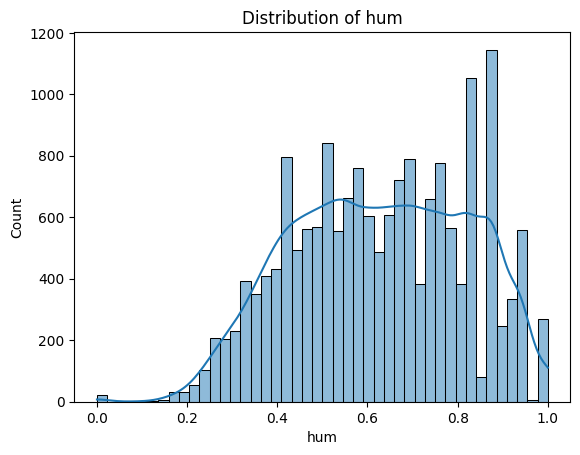

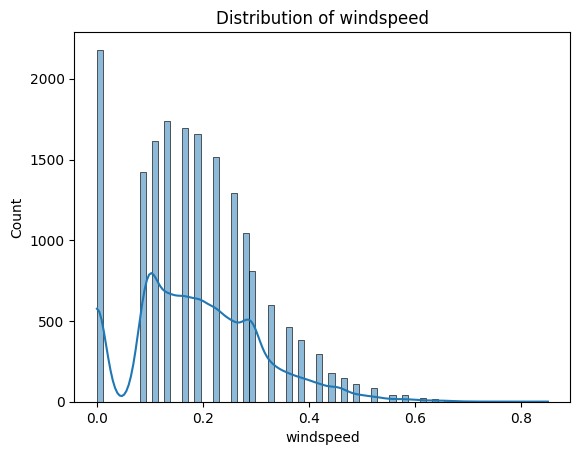

In [10]:
for col in continuous_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [11]:
zscore_cols = ["temp", "atemp", "hum"]

for col in zscore_cols:

    stdd = df[col].std()
    meann = df[col].mean()

    zscore = (df[col] - meann) / stdd

    outlier = df[(zscore < -3) | (zscore > 3)]

    print(f"\n{col} outliers:")
    print(outlier)

    upper_limit = meann + 3 * stdd
    lower_limit = meann - 3 * stdd

    df.loc[zscore > 3, col] = upper_limit
    df.loc[zscore < -3, col] = lower_limit


temp outliers:
Empty DataFrame
Columns: [season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt]
Index: []

atemp outliers:
      season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
4768       3   0     7  14        0        5           1           1  0.96   

      atemp   hum  windspeed  cnt  
4768    1.0  0.48     0.2985  101  

hum outliers:
      season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
1551       1   0     3   0        0        4           1           3  0.34   
1552       1   0     3   1        0        4           1           3  0.34   
1553       1   0     3   2        0        4           1           3  0.34   
1554       1   0     3   5        0        4           1           3  0.36   
1555       1   0     3   6        0        4           1           3  0.36   
1556       1   0     3   7        0        4           1           3  0.38   
1557       1   0     3   8        0        

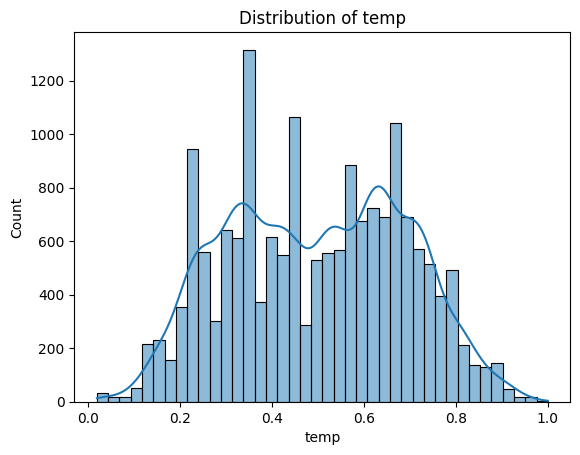

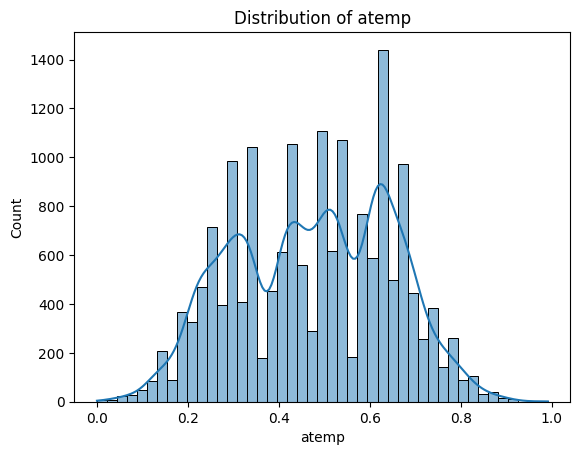

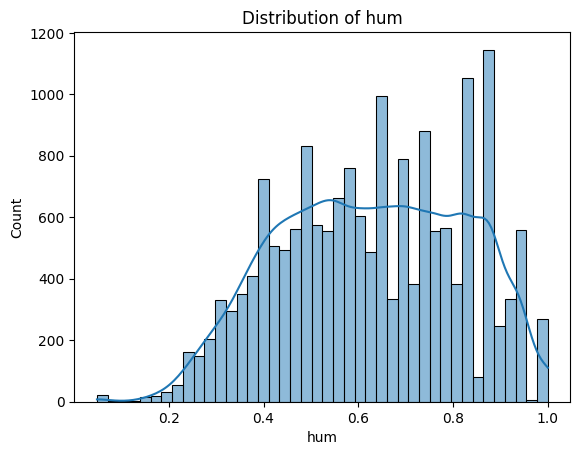

In [12]:
for col in zscore_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

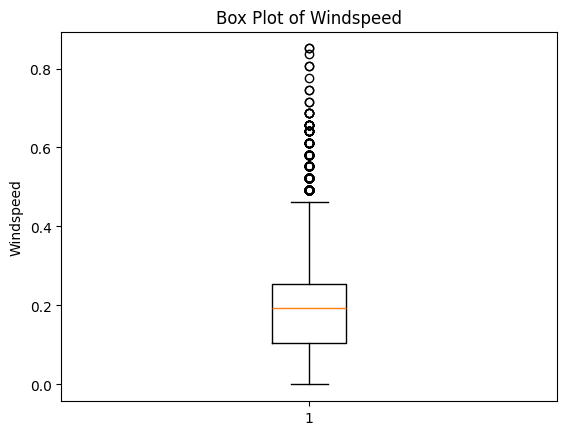

In [13]:
plt.boxplot(df["windspeed"])
plt.title("Box Plot of Windspeed")
plt.ylabel("Windspeed")
plt.show()

In [14]:
Q1 = df["windspeed"].quantile(0.25)
Q3 = df["windspeed"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

IQR = Q3 - Q1
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df.loc[df["windspeed"] > upper_bound, "windspeed"] = upper_bound
df.loc[df["windspeed"] < lower_bound, "windspeed"] = lower_bound

Q1: 0.1045
Q3: 0.2537
IQR: 0.1492
Lower bound: -0.1193
Upper bound: 0.4775


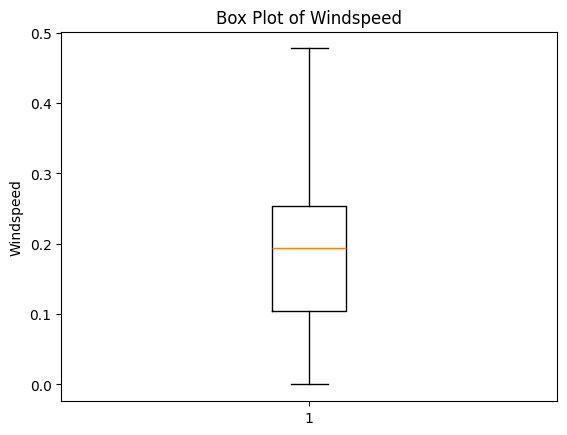

In [15]:
plt.boxplot(df["windspeed"])
plt.title("Box Plot of Windspeed")
plt.ylabel("Windspeed")
plt.show()

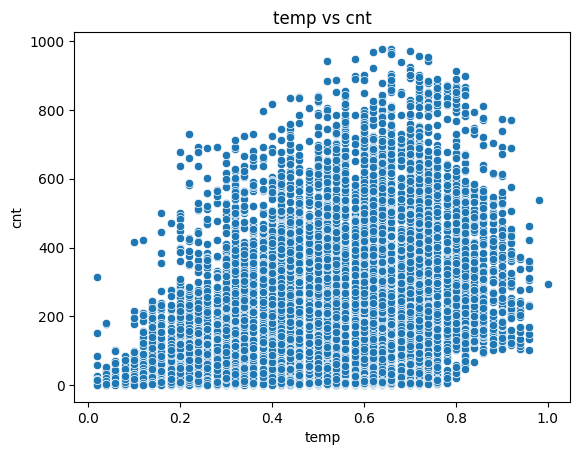

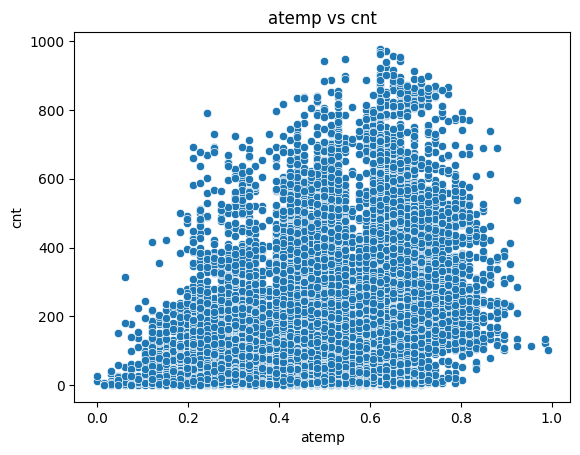

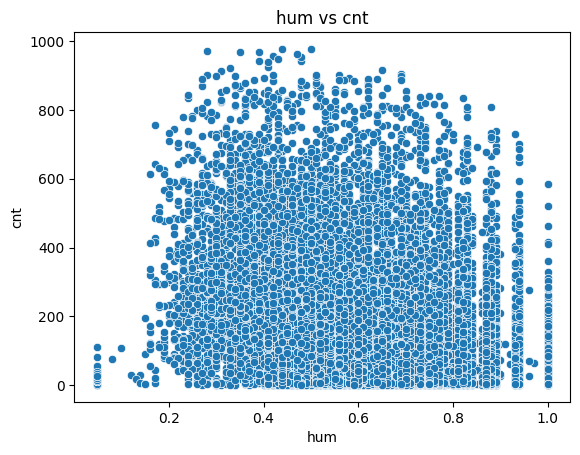

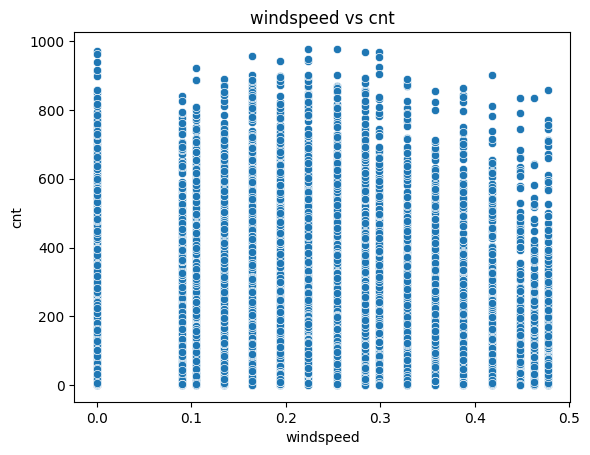

In [16]:
for col in continuous_cols:
    sns.scatterplot(data=df, x=col, y="cnt")
    plt.title(f"{col} vs cnt")
    plt.show()

In [33]:
for col in continuous_cols:
    print(col, df[col].corr(df["cnt"]))

temp 0.4047722757786588
atemp 0.40093424372647785
hum -0.3235146906877478
windspeed 0.09798303819584137


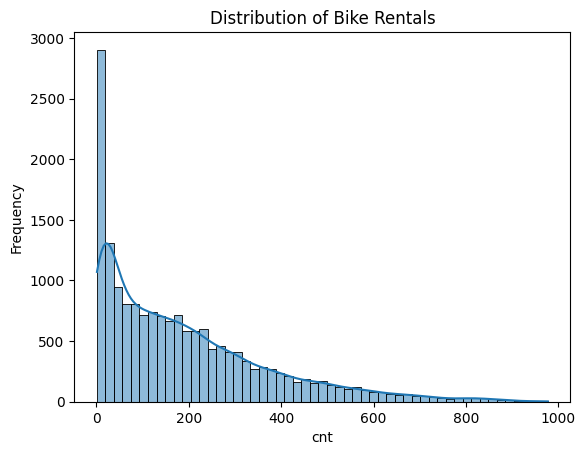

In [32]:
sns.histplot(data=df, x="cnt", kde=True)

plt.title("Distribution of Bike Rentals")
plt.xlabel("cnt")
plt.ylabel("Frequency")

plt.show()

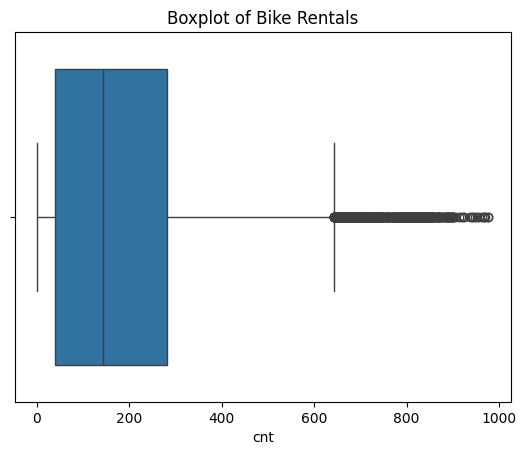

In [31]:
sns.boxplot(x=df["cnt"])

plt.title("Boxplot of Bike Rentals")
plt.xlabel("cnt")

plt.show()


In [30]:
print("Skewness:", df["cnt"].skew())


Skewness: 1.2774116037490577


In [26]:
df["cnt_log"] = np.log1p(df["cnt"])

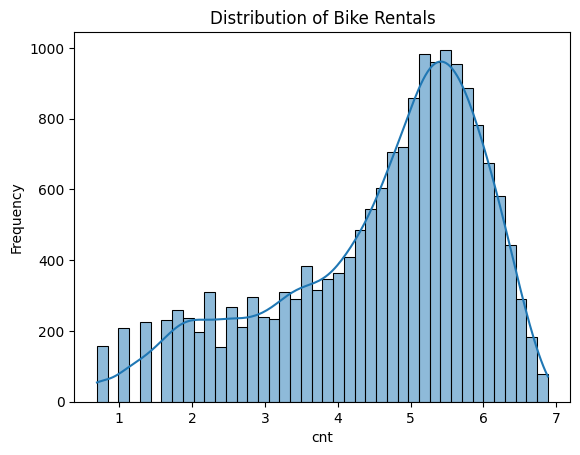

In [34]:
sns.histplot(data=df, x="cnt_log", kde=True)

plt.title("Distribution of Bike Rentals")
plt.xlabel("cnt")
plt.ylabel("Frequency")

plt.show()

In [35]:
print(df.head(2))

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   

    atemp   hum  windspeed  cnt   cnt_log  
0  0.2879  0.81        0.0   16  2.833213  
1  0.2727  0.80        0.0   40  3.713572  


In [36]:
x=df.drop(columns=["cnt","cnt_log"])
y=df["cnt_log"]

In [ ]:
print(x.columns.tolist())

['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']


In [ ]:
print(x.head())

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  casual  registered  
0  0.2879  0.81        0.0       3          13  
1  0.2727  0.80        0.0       8          32  
2  0.2727  0.80        0.0       5          27  
3  0.2879  0.75        0.0       3          10  
4  0.2879  0.75        0.0       0           1  


In [37]:
print(y.head())

0    2.833213
1    3.713572
2    3.496508
3    2.639057
4    0.693147
Name: cnt_log, dtype: float64


In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer([
        ('tf1',OneHotEncoder(sparse_output=False,drop='first'),["season","weathersit","holiday","workingday","weekday","mnth","yr","hr"]),
        ('tf2',StandardScaler(),["temp","atemp","hum","windspeed"])
    ]
    ,remainder='passthrough')

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [58]:
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression

sgd = SGDRegressor(
    learning_rate='constant',
    eta0=0.1,
    random_state=42
)

batch_size = 35
epochs = 100

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train_transformed))

    for start in range(0, len(X_train_transformed), batch_size):
        batch_idx = indices[start:start + batch_size]

        sgd.partial_fit(
            X_train_transformed[batch_idx],
            Y_train.iloc[batch_idx]
        )




In [59]:
y_pred = sgd.predict(X_test_transformed)

result = pd.DataFrame({
    "Actual": Y_test.head(5).values,
    "Predicted": y_pred[:5]
})

print(result)

     Actual  Predicted
0  6.054439   6.619190
1  4.488636   4.192635
2  1.609438   2.631795
3  6.267201   5.715296
4  2.639057   2.902570


In [60]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error

In [61]:
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)


In [62]:
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 0.5132342630709315
Mean Absolute Error: 0.5627331664870723
Root Mean Squared Error: 0.7164037011845565
R-squared: 0.7393191463274527
